# Exploratory Data Analysis: 2024 US Election (Twitter)

This notebook explores the Twitter poll dataset for the 2024 US Presidential Election.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))
from bias_analysis.dataset import get_base_dataset

from loguru import logger
logger.remove()

## 1. Load US24 Dataset

In [3]:
df = get_base_dataset(election="us24")

print(f"Base dataset loaded with {len(df)} polls and {len(df.columns)} features.\n")
print(df.info())
df.head()

Base dataset loaded with 5065 polls and 21 features.

<class 'pandas.DataFrame'>
RangeIndex: 5065 entries, 0 to 5064
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      5065 non-null   str    
 1   author_id                     5065 non-null   str    
 2   created_at                    5065 non-null   str    
 3   tweet_text                    5065 non-null   str    
 4   data_source                   5065 non-null   str    
 5   duration_minutes              5065 non-null   int64  
 6   n_options                     5065 non-null   int64  
 7   total_votes                   5065 non-null   int64  
 8   poll_options                  5065 non-null   str    
 9   user_id                       3367 non-null   str    
 10  author_partisanship_raw       3367 non-null   float64
 11  author_partisanship           3367 non-null   float64
 12  user_id_demo       

,tweet_id,author_id,created_at,tweet_text,data_source,duration_minutes,n_options,total_votes,poll_options,user_id,...,author_partisanship,user_id_demo,author_org_prob,author_gender_male,author_age_under_29,author_age_30_39,author_age_40_over,audience_mean_partisanship,audience_median_partisanship,audience_n_distinct_users
0,1824121434538418657,289514049,Thu Aug 15 16:30:15 +0000 2024,If the US presidential election was held today...,general,10080,4,28,"[{'position': 1, 'label': 'Donald J. Trump', '...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1823996294941102150,1260250316257320960,Thu Aug 15 08:12:59 +0000 2024,🗳️#Election2024: If the 2024 presidential elec...,general,1440,3,29,"[{'position': 1, 'label': 'Donald Trump', 'vot...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1824018730105593856,1183192509578502144,Thu Aug 15 09:42:08 +0000 2024,POTUS? VOTE AND RETWEET PLEASE,general,10080,3,6470,"[{'position': 1, 'label': 'HARRIS-D', 'votes':...",1183192509578502144,...,0.442691,1183192509578502144,0.0000,0.9974,0.0098,0.0107,0.9796,1.856684,1.849045,2217
3,1823918248183681154,1541633364,Thu Aug 15 03:02:51 +0000 2024,Who do you plan to vote for in 2024?,general,720,4,25,"[{'position': 1, 'label': 'Kamala Harris', 'vo...",1541633364,...,-0.000485,1541633364,0.0035,0.9998,0.9957,0.0021,0.0023,1.630498,1.324296,3
4,1824187233609437591,1469517822581788678,Thu Aug 15 20:51:42 +0000 2024,If the 2024 Presidential Election were held to...,general,4320,3,16,"[{'position': 1, 'label': 'Trump', 'votes': 15...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.899677,1.899677,1


## 2. Poll Sources and Distribution

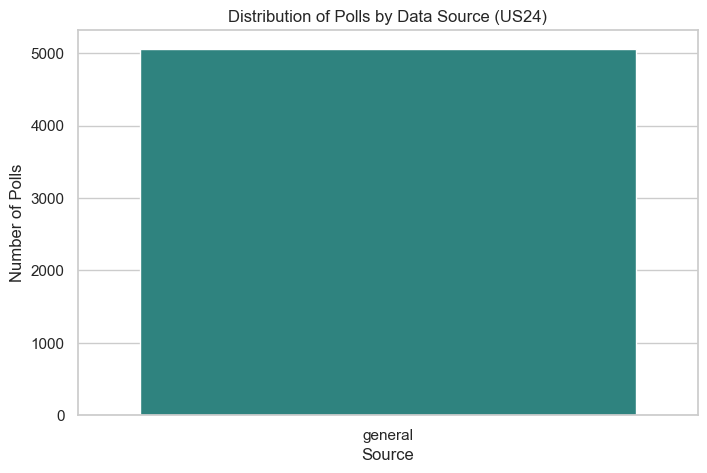

In [4]:
source_counts = df['data_source'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis')
plt.title('Distribution of Polls by Data Source (US24)')
plt.ylabel('Number of Polls')
plt.xlabel('Source')
plt.show()

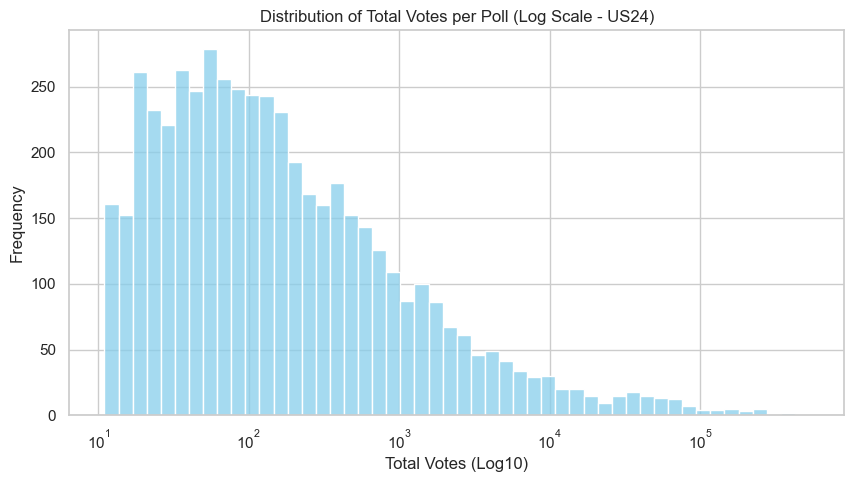

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_votes'].dropna(), bins=50, log_scale=True, color="skyblue")
plt.title('Distribution of Total Votes per Poll (Log Scale - US24)')
plt.xlabel('Total Votes (Log10)')
plt.ylabel('Frequency')
plt.show()

## 3. Author Partisanship

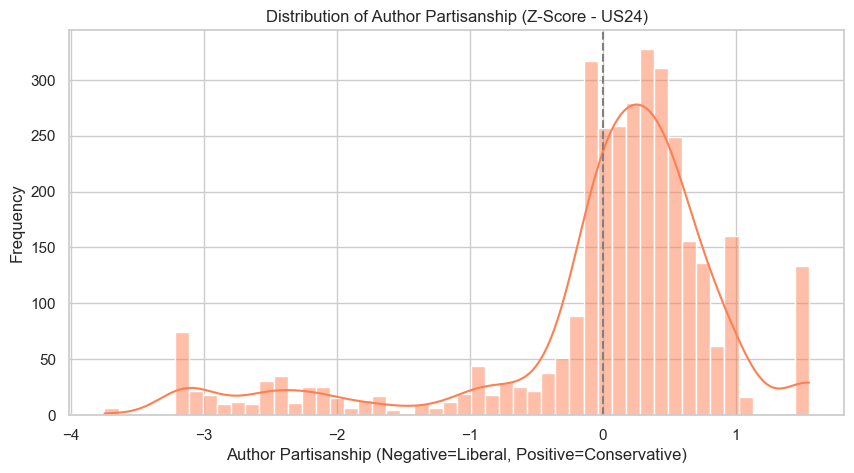

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['author_partisanship'].dropna(), bins=50, color="coral", kde=True)
plt.title('Distribution of Author Partisanship (Z-Score - US24)')
plt.xlabel('Author Partisanship (Negative=Liberal, Positive=Conservative)')
plt.ylabel('Frequency')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

## 4. Audience Partisanship

Analyzing the distribution of the mean partisanship scores of the audience (retweeters/favoriters).

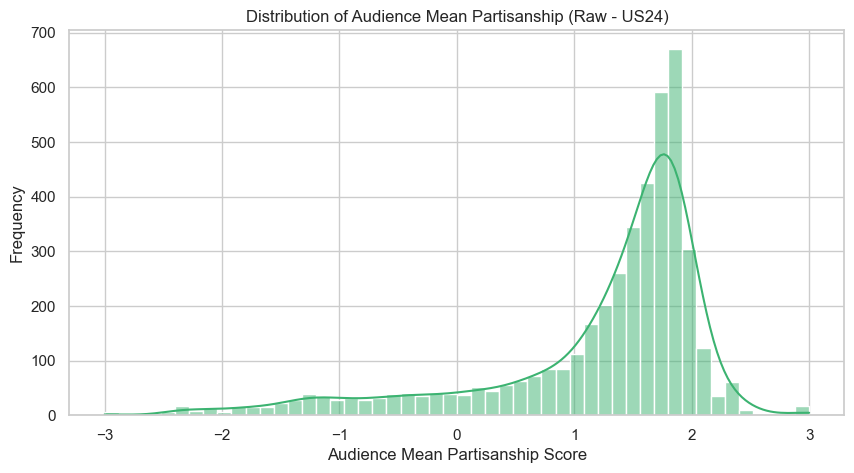

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['audience_mean_partisanship'].dropna(), bins=50, color="mediumseagreen", kde=True)
plt.title('Distribution of Audience Mean Partisanship (Raw - US24)')
plt.xlabel('Audience Mean Partisanship Score')
plt.ylabel('Frequency')
plt.show()

## 5. Author vs Audience Partisanship

Relationship between the poll author's inferred partisanship and their audience's mean partisanship.

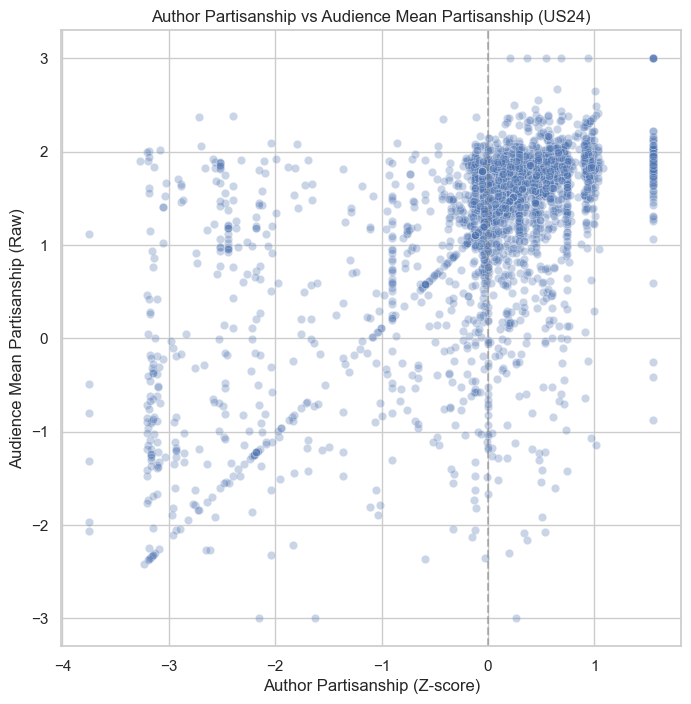

In [8]:
plot_df = df.dropna(subset=['author_partisanship', 'audience_mean_partisanship'])

plt.figure(figsize=(8, 8))
sns.scatterplot(data=plot_df, x='author_partisanship', y='audience_mean_partisanship', alpha=0.3)
plt.title('Author Partisanship vs Audience Mean Partisanship (US24)')
plt.xlabel('Author Partisanship (Z-score)')
plt.ylabel('Audience Mean Partisanship (Raw)')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()